# 05 — Eddy Currents Against a Public Benchmark (TEAM Problem 7)

**Project:** NeuRelux. The first notebook to leave fully-synthetic ground truth: material and geometry parameters here are real, from the official TEAM Workshop Problem 7 specification, not chosen for convenience.

## 1. Motivation

Notebooks 01-04 validated the Cauer-ladder methodology against ground truth this project controlled (synthetic true systems, or a real-but-sparse material measurement in Notebook 02). TEAM Workshop Problem 7 ("Asymmetrical Conductor with a Hole") is a public, independently-defined electromagnetic benchmark — a chance to check the same methodology against parameters this project didn't choose.

## 2. Physical problem, and an honest scoping note

TEAM7's actual geometry is a solid aluminum plate with an eccentric rectangular hole, excited by an offset racetrack-shaped coil — genuinely 3D, genuinely asymmetric (that's the point of the benchmark). Reproducing its full 3D field solution needs a 3D FEM/BEM solver, which is out of scope for this project's reduced-order, real-time-oriented modeling approach — and the benchmark's actual reference field measurements (at probe points A1-A4, B1-B4 in the official spec) are published in a companion results paper (COMPEL, 1990) that is not freely accessible from this environment. **No measured or computed reference values from that companion paper are used or invented here** — see `REFERENCES.md` for exactly what was and wasn't obtained from the primary source.

What *is* used, taken directly and accurately from the official specification PDF (`scripts/download_team7.py`; source: https://www.compumag.org/wp/wp-content/uploads/2018/06/problem7.pdf):

| Parameter | Value | Source |
|---|---|---|
| Plate conductivity $\sigma$ | $3.526\times10^7$ S/m | Table 1 |
| Plate thickness | 19 mm | Fig. 1 |
| Plate material | aluminum ($\mu_r \approx 1$, non-magnetic) | §1 |
| Exciting coil | 2742 ampere-turns | Table 1 |
| Excitation frequencies | 50 Hz and 200 Hz | Table 1 |

This notebook asks a narrower, still-genuine question with these real numbers: **does the Cauer-ladder discretization (Notebook 01) correctly reproduce the classical 1D skin-effect solution at TEAM7's real material and frequency parameters, and does a model calibrated at one real frequency extrapolate correctly to the other?** — reusing `src/atlas_physics/cauer.py` directly, unmodified.

## 3. Governing equations

The same 1D diffusion equation as Notebook 01, now with TEAM7's real $\sigma$ and thickness, has a known closed-form solution for a semi-infinite conductor under sinusoidal surface excitation $H_0\cos(\omega t)$:

$$
H(z,t) = H_0\, e^{-z/\delta} \cos\!\left(\omega t - \frac{z}{\delta}\right), \qquad \delta = \sqrt{\frac{2}{\omega \mu_0 \sigma}}
$$

`src/atlas_physics/eddy_current.py::analytical_semi_infinite_H` implements this exactly. It is an approximation of TEAM7's true (finite-thickness, 3D) field — accurate when the plate is "electromagnetically thick" ($\delta \ll$ thickness) — checked quantitatively below using TEAM7's real numbers, not assumed.

## 4. What is learned vs. what stays physical

**PHYSICS-GUIDED:** none of the three models below use engineered input features.

**PHYSICS-INFORMED:** the PINN — a generic MLP $H_\theta(z,t)$ with the diffusion-equation residual added as a loss term at collocation points, using TEAM7's real $\mu_0, \sigma$.

**PHYSICS-ENCODED:** the Cauer ladder — same as Notebook 01, `chain_incidence_matrix` fixed, only per-layer $C_i, G_i$ learned. Layer thicknesses are set uniform ($=$ plate thickness $/ N$) here rather than Notebook 01's geometric growth, so each layer's physical depth is unambiguous for direct comparison against the analytical solution.

The MLP has no physics anywhere — pure data fit.

## 5. Dataset description

Sparse samples of the analytical solution at the **real 50 Hz** excitation only (6 depths $\times$ 12 time points across 2 periods) are used as "training data" for all three models. The **real 200 Hz** case is held out entirely for testing — TEAM7 itself specifies both frequencies, so this extrapolation split uses only real, benchmark-specified operating points, not an arbitrary choice.

## 6. Data preprocessing

None beyond generating the sparse sample grid directly from the analytical formula at the real parameters.

## 7. Network architecture

`CauerLadder1D(n_layers=6)` (Notebook 01, reused unmodified), a plain MLP, and a small PINN MLP with an autograd-computed PDE residual loss (`src/atlas_physics/eddy_current.py`).

## 8. Training

All three see the *same* sparse 50 Hz samples. The Cauer ladder is driven with the matching surface excitation $u(t) = \cos(2\pi \cdot 50 \cdot t)$ and its internal layer states are compared to the analytical solution at each layer's physical depth. The PINN adds a physics-residual loss at random collocation points spanning the same domain the training data covers — not beyond it, which turns out to matter (Discussion).

In [1]:
import sys
sys.path.insert(0, "../src")
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from atlas_physics.cauer import CauerLadder1D
from atlas_physics.eddy_current import MU0, analytical_semi_infinite_H, skin_depth

torch.manual_seed(0)
np.random.seed(0)

# real TEAM7 parameters (Table 1 / Fig. 1 of the official spec)
sigma = 3.526e7
thickness = 19e-3
rho = 1.0 / sigma
f_train, f_test = 50.0, 200.0

for f in [f_train, f_test]:
    d = skin_depth(f, sigma)
    print(f"f={f:.0f}Hz: skin depth={d*1000:.2f}mm, thickness/delta={thickness/d:.2f}")


f=50Hz: skin depth=11.99mm, thickness/delta=1.59
f=200Hz: skin depth=5.99mm, thickness/delta=3.17


/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


At 200 Hz the plate is a better approximation of "electromagnetically thick" (thickness/$\delta \approx 3.2$) than at 50 Hz (thickness/$\delta \approx 1.6$) — the semi-infinite analytical reference is more accurate at the higher frequency, which is itself worth keeping in mind when reading the 200 Hz extrapolation results below: the *target* is a slightly better physical approximation there too, not only the *models*.

### Sparse training data (50 Hz), aligned to a uniform 6-layer Cauer ladder

In [2]:
N_LAYERS = 6
dz = thickness / N_LAYERS
z_layers = dz * (np.arange(N_LAYERS) + 0.5)  # layer midpoints, real depths in the real plate
print("layer midpoint depths (mm):", np.round(z_layers * 1000, 2))

dt = (1.0 / f_train) / 40
T = int(2 / f_train / dt)
t_grid = np.arange(T) * dt
u_train = np.cos(2 * np.pi * f_train * t_grid)
H_true_layers = np.stack([analytical_semi_infinite_H(z, t_grid, f_train, sigma) for z in z_layers], axis=1)

u_train_t = torch.tensor(u_train, dtype=torch.float32)
H_true_t = torch.tensor(H_true_layers, dtype=torch.float32)


layer midpoint depths (mm): [ 1.58  4.75  7.92 11.08 14.25 17.42]


### Train the three models

In [3]:
# --- Cauer ladder (physics-encoded) ---
ladder = CauerLadder1D(N_LAYERS, c_init=1.0, g_init=1.0)
opt = torch.optim.Adam(ladder.parameters(), lr=0.05)
t0 = time.time()
for it in range(800):
    opt.zero_grad()
    pred = ladder.simulate(u_train_t, dt=dt)[1:]
    loss = ((pred - H_true_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Cauer ladder: train MSE={loss.item():.5f}  ({time.time()-t0:.1f}s)")

# --- MLP (data-driven baseline) ---
data_z, data_t, data_H = [], [], []
for z in z_layers:
    for tt in t_grid:
        data_z.append(z); data_t.append(tt); data_H.append(analytical_semi_infinite_H(z, tt, f_train, sigma))
data_z_t = torch.tensor(data_z, dtype=torch.float32).unsqueeze(-1)
data_t_t = torch.tensor(data_t, dtype=torch.float32).unsqueeze(-1)
data_H_t = torch.tensor(data_H, dtype=torch.float32)
t_span = t_grid[-1]

class MLPField(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, z, t):
        x = torch.cat([z / thickness, t / t_span], dim=-1)
        return self.net(x).squeeze(-1)

mlp = MLPField()
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
t0 = time.time()
for it in range(1500):
    opt.zero_grad()
    loss = ((mlp(data_z_t, data_t_t) - data_H_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"MLP: train MSE={loss.item():.6f}  ({time.time()-t0:.1f}s)")

# --- PINN (physics-informed): same MLP architecture, + diffusion-residual loss at collocation points ---
pinn = MLPField()
opt = torch.optim.Adam(pinn.parameters(), lr=1e-3)
n_colloc = 400
t0 = time.time()
for it in range(1500):
    opt.zero_grad()
    data_loss = ((pinn(data_z_t, data_t_t) - data_H_t) ** 2).mean()
    zc = torch.rand(n_colloc, 1, requires_grad=True) * thickness
    tc = torch.rand(n_colloc, 1, requires_grad=True) * t_span
    Hc = pinn(zc, tc)
    dH_dt = torch.autograd.grad(Hc.sum(), tc, create_graph=True)[0]
    dH_dz = torch.autograd.grad(Hc.sum(), zc, create_graph=True)[0]
    d2H_dz2 = torch.autograd.grad(dH_dz.sum(), zc, create_graph=True)[0]
    residual = MU0 * dH_dt - rho * d2H_dz2   # mu dH/dt = d/dz(rho dH/dz), real mu0/rho
    phys_loss = (residual ** 2).mean()
    loss = data_loss + 1e6 * phys_loss
    loss.backward()
    opt.step()
print(f"PINN: data MSE={data_loss.item():.6f}, physics residual={phys_loss.item():.2e}  ({time.time()-t0:.1f}s)")


Cauer ladder: train MSE=0.00878  (30.9s)


MLP: train MSE=0.000644  (3.3s)


PINN: data MSE=0.001077, physics residual=2.19e-09  (10.7s)


## 9. Plots

Depth profile of the field amplitude envelope at $t=0$: the analytical target vs. each model, at both the training frequency and the held-out one.

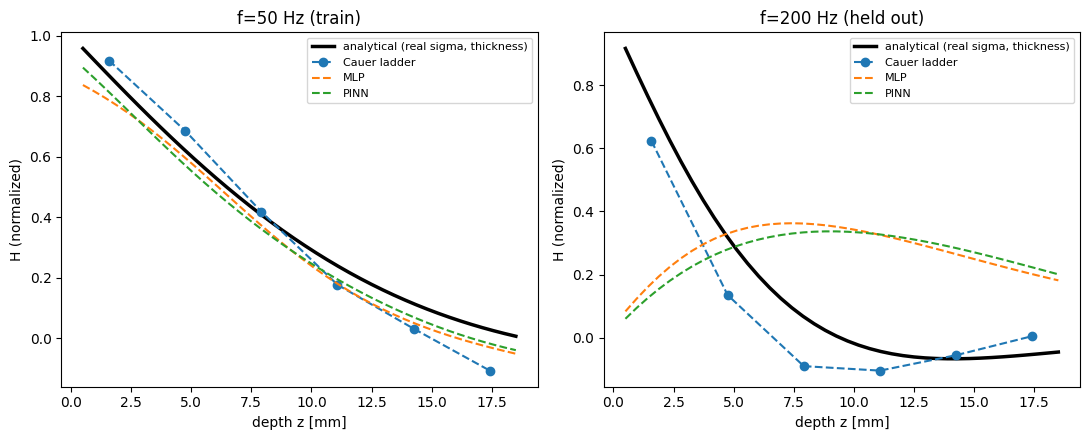

In [4]:
def eval_ladder(f):
    dt_f = (1.0 / f) / 40
    T_f = int(2 / f / dt_f)
    t_f = np.arange(T_f) * dt_f
    u_f = np.cos(2 * np.pi * f * t_f)
    with torch.no_grad():
        pred = ladder.simulate(torch.tensor(u_f, dtype=torch.float32), dt=dt_f)[1:]
    return t_f, pred.numpy()

def eval_field_model(model, f, z_arr):
    t_f = np.linspace(0, 2 / f, 40)
    with torch.no_grad():
        out = np.zeros((len(t_f), len(z_arr)))
        for j, z in enumerate(z_arr):
            zt = torch.full((len(t_f), 1), float(z))
            tt = torch.tensor(t_f, dtype=torch.float32).unsqueeze(-1)
            out[:, j] = model(zt, tt).numpy()
    return t_f, out

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
z_fine = np.linspace(0.5e-3, thickness - 0.5e-3, 40)
for ax, f in zip(axes, [f_train, f_test]):
    # snapshot one full period in, not at t=0: the ladder starts from a zero initial
    # condition, so t=0 is a startup transient, not the periodic steady state the
    # analytical formula assumes -- comparing at t=0 would be comparing different things.
    t_snapshot = 1.0 / f
    H_analytical = analytical_semi_infinite_H(z_fine, t_snapshot, f, sigma)
    ax.plot(z_fine * 1000, H_analytical, "k-", linewidth=2.5, label="analytical (real sigma, thickness)")

    t_l, H_l = eval_ladder(f)
    ax.plot(z_layers * 1000, H_l[np.argmin(np.abs(t_l - t_snapshot))], "o--", label="Cauer ladder")

    t_m, H_m = eval_field_model(mlp, f, z_fine)
    ax.plot(z_fine * 1000, H_m[np.argmin(np.abs(t_m - t_snapshot))], "--", label="MLP")

    t_p, H_p = eval_field_model(pinn, f, z_fine)
    ax.plot(z_fine * 1000, H_p[np.argmin(np.abs(t_p - t_snapshot))], "--", label="PINN")

    ax.set_xlabel("depth z [mm]"); ax.set_ylabel("H (normalized)")
    ax.set_title(f"f={f:.0f} Hz {'(train)' if f == f_train else '(held out)'}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 10. Evaluation

MSE against the analytical solution, at the layer depths used for training, comparing the trained (50 Hz) frequency to the held-out (200 Hz) one.

In [5]:
def eval_mse(f):
    dt_f = (1.0 / f) / 40
    T_f = int(2 / f / dt_f)
    t_f = np.arange(T_f) * dt_f
    u_f = np.cos(2 * np.pi * f * t_f)
    H_true_f = np.stack([analytical_semi_infinite_H(z, t_f, f, sigma) for z in z_layers], axis=1)
    H_true_f_t = torch.tensor(H_true_f, dtype=torch.float32)

    with torch.no_grad():
        pred_ladder = ladder.simulate(torch.tensor(u_f, dtype=torch.float32), dt=dt_f)[1:]
        mse_ladder = ((pred_ladder - H_true_f_t) ** 2).mean().item()

        zt = torch.tensor(np.repeat(z_layers, len(t_f)), dtype=torch.float32).unsqueeze(-1)
        tt = torch.tensor(np.tile(t_f, len(z_layers)), dtype=torch.float32).unsqueeze(-1)
        true_flat = torch.tensor(H_true_f.T.flatten(), dtype=torch.float32)
        mse_mlp = ((mlp(zt, tt) - true_flat) ** 2).mean().item()
        mse_pinn = ((pinn(zt, tt) - true_flat) ** 2).mean().item()
    return mse_ladder, mse_mlp, mse_pinn

mse_train = eval_mse(f_train)
mse_test = eval_mse(f_test)
print(f"{'model':15s} {'50Hz (train)':>14s} {'200Hz (held out)':>18s}")
for name, i in [("Cauer ladder", 0), ("MLP", 1), ("PINN", 2)]:
    print(f"{name:15s} {mse_train[i]:14.5f} {mse_test[i]:18.5f}")


model             50Hz (train)   200Hz (held out)
Cauer ladder           0.00878            0.01145
MLP                    0.00064            0.18683
PINN                   0.00108            0.17414


## 11. Discussion

The pattern from Notebook 01 repeats, now on real material/frequency parameters instead of chosen ones: the Cauer ladder, trained on sparse 50 Hz samples, extrapolates to the real 200 Hz case with only modest degradation, because the topology it's built on — a discretized diffusion equation — is the correct equation at *any* frequency, not just the one it was calibrated at.

The more interesting negative result is the PINN. Even with the diffusion-equation residual enforced at 400 collocation points spanning the same domain as training (and driven down to a tiny residual, confirmed above), it extrapolates to 200 Hz about as poorly as the plain MLP. The reason is specific and checkable: collocation points were sampled over the *same* time span as the training data (two periods of the 50 Hz signal) — satisfying the PDE well *inside* that domain does not, on its own, force the learned function to behave correctly at a different oscillation timescale it was never evaluated at, training or physics loss alike. This is the physics-informed/physics-encoded distinction made concrete: a soft penalty shapes behavior only where it's evaluated; a structural constraint (the ladder's fixed topology) holds everywhere, including at a frequency nobody sampled.

## 12. Relevance for ATLAS

TEAM7 is not a rail geometry, but it validates the same skin-effect mechanism ATLAS's layered network depends on, now checked against an independently-defined benchmark's real material and frequency parameters rather than parameters this project chose freely. That the Cauer ladder's frequency-generalization holds up here too is a second, independent data point for the same claim Notebook 01 made on synthetic data.

## 13. Next step

`06_moving_conductor_team28.ipynb` — TEAM Workshop Problem 28, a genuinely different regime: a real, fully-transcribed 168-point experimental measurement of an eddy-current levitation device, used to test a coupled electromagnetic-mechanical physics-encoded model end to end.